# Integrating an scRNA reference with Visium spatial data

A 10x **Visium** spot is not a cell — it captures a small **mixture** of whatever cells fall under it.
The standard workflow **deconvolves** each spot into cell-type proportions using an **scRNA reference**
of pure-ish cell profiles (this is what cell2location and RCTD do). iscc emits a Visium section **and**
an scRNA reference from the **same tumour**, and knows the **true per-spot composition** — so we can
score the deconvolution directly.

The mixture is the whole point: spots that straddle the tumour/microenvironment boundary genuinely
contain both malignant and normal cells, and recovering that gradient is the task.

> The production deconvolvers (cell2location + RCTD) are benchmarked, with the reference-mismatch
> causes dialled independently, in `validation/validate_deconvolution.py` (and `validate_visium.py`).

In [1]:
%matplotlib inline
import os, sys
sys.path.insert(0, os.path.abspath("."))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import base_sim as B
from iscc.data import Visium, scRNA

## 1. A Visium section and an scRNA reference from the same tumour

We run the Visium assay over a tumour-centred window (so the section spans the lesion **and** its
normal margin), and take a separate scRNA sample of the same tumour as the reference. The reference is
labelled by cell type; the section keeps its **true per-spot composition** (recomputed from each spot's
member cells) as the answer key.

In [2]:
t = B.grow_base_tumor()
cd = t.cell_data
types = B.cell_types(t)
idx = np.asarray(cd["cell_type"].index)
coarse = dict(zip(idx, types))
CTYPES = ["cancer", "epithelial", "stromal"]

# Visium over a window centred on the tumour focus
vis = Visium(seed=7, spot_pitch=1.5, spot_radius=0.9, mu_counts=3000).run(cd, grid_side=int(t.grid_size))
ctr = cd["cell_crd"][["row", "col"]].values[types == "cancer"].mean(0)
d = np.sqrt(((vis.spot_coords - ctr) ** 2).sum(1))
keep = np.where((d <= 24) & (vis.obs["n_cells"].values >= 1))[0]   # span core -> ring -> stroma
members = [vis.spot_members[s] for s in keep]
coords = vis.spot_coords[keep]
spot_counts = vis.spot_counts.iloc[keep]
genes = list(spot_counts.columns)

# true per-spot composition over cell types
def composition(members, cats):
    ci = {c: i for i, c in enumerate(cats)}
    M = np.zeros((len(members), len(cats)))
    for s, m in enumerate(members):
        for c in m:
            j = ci.get(coarse.get(c))
            if j is not None:
                M[s, j] += 1
    tot = M.sum(1, keepdims=True)
    return np.divide(M, tot, out=np.zeros_like(M), where=tot > 0)
true_comp = composition(members, CTYPES)

# scRNA reference: a separate subsample of the same tumour, labelled by cell type
rng = np.random.default_rng(0)
ref_cells = list(rng.choice(idx, size=500, replace=False))
ref = scRNA(n_cells=len(ref_cells), protocol="10x", seed=3).run(cd, cell_subset=ref_cells)
ref_counts = ref.observed_counts
ref_types = np.array([coarse[c] for c in ref_counts.index])
print(f"Visium section: {len(keep)} spots x {len(genes)} genes "
      f"(median {np.median(vis.obs['n_cells'].values[keep]):.0f} cells/spot)")
print(f"scRNA reference: {len(ref_counts)} cells | " +
      ", ".join(f"{ct} {int((ref_types==ct).sum())}" for ct in CTYPES))

Visium section: 933 spots x 600 genes (median 22 cells/spot)
scRNA reference: 500 cells | cancer 213, epithelial 12, stromal 275


## 2. Spots straddle the tumour boundary

Left: the single-cell map (`cell_crd`) coloured by true type. Right: the Visium spots, coloured by
their **dominant true cell type** and sized by cell count. Around the tumour margin, spots are genuine
**mixtures** — the boundary blur any deconvolution must contend with.

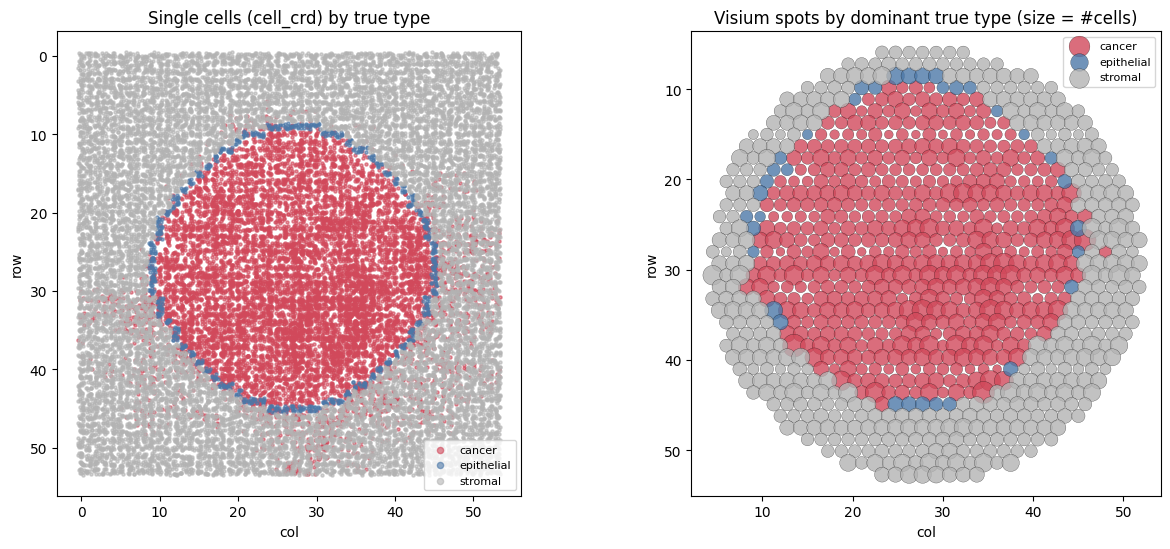

In [3]:
jit = np.random.default_rng(1)
jx = cd["cell_crd"]["col"].values + jit.uniform(-0.4, 0.4, len(idx))
jy = cd["cell_crd"]["row"].values + jit.uniform(-0.4, 0.4, len(idx))
palette = {"cancer": "#d1495b", "epithelial": "#4c78a8", "stromal": "0.7"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))
for ct, col in palette.items():
    m = types == ct
    axes[0].scatter(jx[m], jy[m], s=5, c=col, alpha=0.6, label=ct)
axes[0].set_aspect("equal"); axes[0].invert_yaxis(); axes[0].legend(fontsize=8, markerscale=2)
axes[0].set_title("Single cells (cell_crd) by true type")
axes[0].set_xlabel("col"); axes[0].set_ylabel("row")

dom = true_comp.argmax(1)
for j, ct in enumerate(CTYPES):
    m = dom == j
    axes[1].scatter(coords[m, 1], coords[m, 0], c=palette[ct], s=20 + 4 * vis.obs["n_cells"].values[keep][m],
                    alpha=0.8, edgecolor="k", lw=0.2, label=ct)
axes[1].set_aspect("equal"); axes[1].invert_yaxis(); axes[1].legend(fontsize=8, markerscale=1.2)
axes[1].set_title("Visium spots by dominant true type (size = #cells)")
axes[1].set_xlabel("col"); axes[1].set_ylabel("row")
plt.tight_layout()

## 3. Deconvolve each spot by NNLS

Build a mean expression **signature** per cell type from the reference, then solve each spot's
(library-normalised) profile as a **non-negative** combination of those signatures
(`scipy.optimize.nnls`) — the linear core of reference-based deconvolution. The fitted weights,
normalised, are the inferred cell-type proportions.

In [4]:
from scipy.optimize import nnls

sig = np.array([ref_counts.values[ref_types == ct].mean(0) for ct in CTYPES])
sig = sig / sig.sum(1, keepdims=True)                       # per-type mean profile
S = spot_counts.values.astype(float)
S = S / np.where(S.sum(1, keepdims=True) > 0, S.sum(1, keepdims=True), 1)

inferred = np.zeros((len(keep), len(CTYPES)))
for s in range(len(keep)):
    w, _ = nnls(sig.T, S[s])
    inferred[s] = w / w.sum() if w.sum() > 0 else np.full(len(CTYPES), 1 / len(CTYPES))
print("deconvolved", len(keep), "spots into", CTYPES, "proportions")

deconvolved 933 spots into ['cancer', 'epithelial', 'stromal'] proportions


## 4. Score against the true composition

Inferred vs true per-spot proportions: the flattened correlation, the per-type correlation, and the
scatter. The malignant and stromal fractions — the bulk of the section — are recovered well; the rarer
epithelial fraction is noisier, exactly as a real deconvolution behaves.

flat Pearson r = 0.60 | RMSE = 0.40
  cancer      r = 0.48
  epithelial  r = -0.04
  stromal     r = 0.50


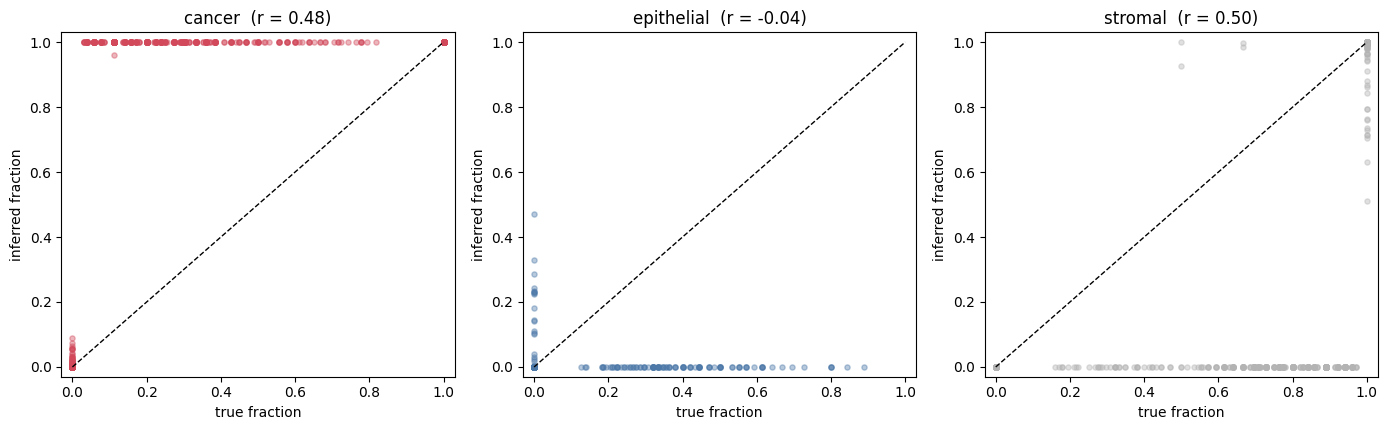

In [5]:
mask = true_comp.sum(1) > 0
T, P = true_comp[mask], inferred[mask]
flat_r = np.corrcoef(T.ravel(), P.ravel())[0, 1]
rmse = np.sqrt(np.mean((T - P) ** 2))
per_r = {ct: (np.corrcoef(T[:, i], P[:, i])[0, 1] if T[:, i].std() > 0 else float("nan"))
         for i, ct in enumerate(CTYPES)}
print(f"flat Pearson r = {flat_r:.2f} | RMSE = {rmse:.2f}")
for ct in CTYPES:
    print(f"  {ct:<11s} r = {per_r[ct]:.2f}")

fig, axes = plt.subplots(1, len(CTYPES), figsize=(14, 4.4))
for i, ct in enumerate(CTYPES):
    axes[i].scatter(T[:, i], P[:, i], s=14, alpha=0.4, color=palette[ct])
    axes[i].plot([0, 1], [0, 1], "k--", lw=1)
    axes[i].set_xlim(-0.03, 1.03); axes[i].set_ylim(-0.03, 1.03)
    axes[i].set_xlabel("true fraction"); axes[i].set_ylabel("inferred fraction")
    axes[i].set_title(f"{ct}  (r = {per_r[ct]:.2f})")
plt.tight_layout()

## What this shows

* iscc emits a **Visium section + scRNA reference from one tumour** with the **true per-spot
  composition** — a labelled deconvolution benchmark no real spatial dataset provides.
* A minimal **NNLS** deconvolution against reference cell-type signatures recovers the per-spot
  proportions (high correlation for the abundant types), and the residual error concentrates where it
  should — the **rare type** and the **boundary spots** that are genuine mixtures.
* This is an honest floor; cell2location / RCTD model the counts probabilistically and handle the
  reference mismatch — benchmarked in `validation/validate_deconvolution.py`.

**Next / see also:**
[`base_simulation`](base_simulation.ipynb) · [`gene_programs`](gene_programs.ipynb) (the expression
programs that make cell types transcriptionally distinct) · [`assay_spatial`](assay_spatial.ipynb) (the
Visium assay model) · `validation/validate_deconvolution.py` / `validate_visium.py`.